In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [55]:
gender_df = pd.read_csv("gender_submission.csv")
test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")
test_passenger_ids = test_df["PassengerId"]

In [3]:
gender_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [4]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
survival_count = train_df["Survived"].value_counts()
print(survival_count)

Survived
0    549
1    342
Name: count, dtype: int64


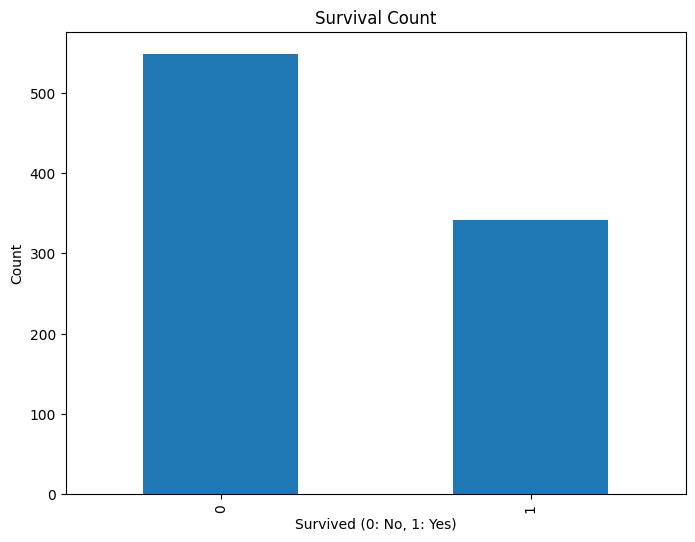

In [7]:
plt.figure(figsize=(8, 6))
survival_count.plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

In [8]:
print(gender_df["PassengerId"].head())
print(test_df["PassengerId"].head())
print(train_df["PassengerId"].head())

0    892
1    893
2    894
3    895
4    896
Name: PassengerId, dtype: int64
0    892
1    893
2    894
3    895
4    896
Name: PassengerId, dtype: int64
0    1
1    2
2    3
3    4
4    5
Name: PassengerId, dtype: int64


In [9]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
train_df = pd.get_dummies(train_df, columns=["Embarked"])

In [11]:
test_df = pd.get_dummies(test_df, columns=["Embarked"])

In [12]:
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})

In [13]:
test_df["Sex"] = test_df["Sex"].map({"male": 0, "female": 1})

In [14]:
test_df["Age"].isna().sum()

np.int64(86)

In [15]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,True,False,False


# Filling Age null Values using Random Forest


In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
def fillAge(df):
    age_feature = [
        "Pclass",
        "Sex",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S",
    ]
    known_age = df[df["Age"].notnull()]
    unknown_age = df[df["Age"].isnull()]
    x_train = known_age[age_feature]
    y_train = known_age["Age"]

    x_test = unknown_age[age_feature]
    rf = RandomForestRegressor(n_estimators=100, random_state=42)

    rf.fit(x_train, y_train)

    predicted_ages = rf.predict(x_test)
    df.loc[df["Age"].isnull(), "Age"] = predicted_ages

    return df

In [18]:
fillAge(test_df)
fillAge(train_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False


In [19]:
train_df["Age"].isna().sum()

np.int64(0)

In [20]:
test_df["Age"].isna().sum()

np.int64(0)

In [21]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,NaN,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False


In [22]:
# Family Size
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

# IsAlone
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)

# Cabin (has or not)
train_df["HasCabin"] = train_df["Cabin"].notnull().astype(int)

In [23]:
# Family Size
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1

# IsAlone
test_df["IsAlone"] = (test_df["FamilySize"] == 1).astype(int)

# Cabin (has or not)
test_df["HasCabin"] = test_df["Cabin"].notnull().astype(int)

In [24]:
train_df["Cabin"].isna().sum()

np.int64(687)

In [25]:
print(train_df["Cabin"].isnull().sum(), "out of", train_df.shape[0])

687 out of 891


In [26]:
print(test_df["Cabin"].isnull().sum(), "out of", test_df.shape[0])

327 out of 418


In [27]:
train_df["Cabin"].value_counts

<bound method IndexOpsMixin.value_counts of 0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object>

In [28]:
test_df["Cabin"].value_counts

<bound method IndexOpsMixin.value_counts of 0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
413     NaN
414    C105
415     NaN
416     NaN
417     NaN
Name: Cabin, Length: 418, dtype: object>

In [29]:
df1 = train_df.drop(["Cabin"], axis=1)
df2 = train_df.copy()
df2["Cabin"] = df2["Cabin"].fillna("Unknown")

In [30]:
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,False,False,True,2,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,True,False,False,2,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,False,False,True,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,False,False,True,2,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,False,False,True,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,False,False,True,1,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,False,False,True,1,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,False,False,True,4,0,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,True,False,False,1,1,1


In [31]:
test1 = test_df.drop(["Cabin"], axis=1)
test2 = test_df.copy()
test2["Cabin"] = test2["Cabin"].fillna("Unknown")

In [32]:
df2["Cabin_letter"] = train_df["Cabin"].astype(str).str[0]
df2["Cabin_letter"].replace("n", "u", inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15504\3027342741.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Cabin_letter"].replace("n", "u", inplace=True)


In [33]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin,Cabin_letter
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,Unknown,False,False,True,2,0,0,u
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False,2,0,1,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True,1,1,0,u
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True,2,0,1,C
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,Unknown,False,False,True,1,1,0,u
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,Unknown,False,False,True,1,1,0,u
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True,1,1,1,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,Unknown,False,False,True,4,0,0,u
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False,1,1,1,C


In [34]:
test2["Cabin_letter"] = test_df["Cabin"].astype(str).str[0]
test2["Cabin_letter"].replace("n", "u", inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15504\1227855287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test2["Cabin_letter"].replace("n", "u", inplace=True)


In [35]:
df2 = train_df.copy()
df2["Cabin"] = df2["Cabin"].fillna("Unknown")
df2["Cabin_letter"] = df2["Cabin"].astype(str).str[0]
df2["Cabin_letter"] = df2["Cabin_letter"].replace("n", "u")

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2["Cabin_letter"] = le.fit_transform(df2["Cabin_letter"])
test2["Cabin_letter"] = le.fit_transform(test2["Cabin_letter"])

In [37]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin,Cabin_letter
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000,1,0,A/5 21171,7.2500,Unknown,False,False,True,2,0,0,8
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000,1,0,PC 17599,71.2833,C85,True,False,False,2,0,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000,0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True,1,1,0,8
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000,1,0,113803,53.1000,C123,False,False,True,2,0,1,2
4,5,0,3,"Allen, Mr. William Henry",0,35.000,0,0,373450,8.0500,Unknown,False,False,True,1,1,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000,0,0,211536,13.0000,Unknown,False,False,True,1,1,0,8
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000,0,0,112053,30.0000,B42,False,False,True,1,1,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,15.855,1,2,W./C. 6607,23.4500,Unknown,False,False,True,4,0,0,8
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000,0,0,111369,30.0000,C148,True,False,False,1,1,1,2


In [38]:
x1_train = df1.sample(frac=1).drop(["Name", "Ticket", "Survived"], axis=1)
x2_train = df2.sample(frac=1).drop(["Survived", "Cabin", "Name", "Ticket"], axis=1)
y_train = train_df.sample(frac=1)["Survived"]

In [39]:
gender_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [40]:
x1_test = test1.drop(["Name", "Ticket"], axis=1)
x2_test = test2.drop(["Cabin", "Name", "Ticket"], axis=1)
y_test = gender_df["Survived"]

In [41]:
x1_train.astype(int)
x2_train.astype(int)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin,Cabin_letter
278,279,3,0,7,4,1,29,0,1,0,6,0,0,8
95,96,3,0,30,0,0,8,0,0,1,1,1,0,8
850,851,3,0,4,4,2,31,0,0,1,7,0,0,8
14,15,3,1,14,0,0,7,0,0,1,1,1,0,8
53,54,2,1,29,1,0,26,0,0,1,2,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,52,3,0,21,0,0,7,0,0,1,1,1,0,8
91,92,3,0,20,0,0,7,0,0,1,1,1,0,8
748,749,1,0,19,1,0,53,0,0,1,2,0,1,3
601,602,3,0,27,0,0,7,0,0,1,1,1,0,8


In [42]:
x1_test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin
0,892,3,0,34.500000,0,0,7.8292,False,True,False,1,1,0
1,893,3,1,47.000000,1,0,7.0000,False,False,True,2,0,0
2,894,2,0,62.000000,0,0,9.6875,False,True,False,1,1,0
3,895,3,0,27.000000,0,0,8.6625,False,False,True,1,1,0
4,896,3,1,22.000000,1,1,12.2875,False,False,True,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,26.370706,0,0,8.0500,False,False,True,1,1,0
414,1306,1,1,39.000000,0,0,108.9000,True,False,False,1,1,1
415,1307,3,0,38.500000,0,0,7.2500,False,False,True,1,1,0
416,1308,3,0,26.370706,0,0,8.0500,False,False,True,1,1,0


In [ ]:
# Fill NaN values in Fare with KNN
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
x1_test[["Fare"]] = imputer.fit_transform(x1_test[["Fare"]])

# # Fill NaN values in Fare with mean

# x1_test["Fare"] = x1_test["Fare"].fillna(x1_test["Fare"].mean())


# Convert to int after handling NaN values


x1_test = x1_test.astype(int)


# Same for x2_test

imputer = KNNImputer(n_neighbors=5)
x2_test[["Fare"]] = imputer.fit_transform(x2_test[["Fare"]])

# x2_test["Fare"] = x2_test["Fare"].fillna(x2_test["Fare"].mean())


x2_test = x2_test.astype(int)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = ["Age", "Fare"]

# Convert x1_train to DataFrame if it's not already
x1_train = pd.DataFrame(x1_train) if isinstance(x1_train, np.ndarray) else x1_train

# Standardize numerical features for training set
x1_train[numerical_features] = scaler.fit_transform(x1_train[numerical_features])

# Standardize numerical features for test set
x1_test[numerical_features] = scaler.transform(x1_test[numerical_features])

In [45]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x1_train_resampled, y_train_resampled = smote.fit_resample(x1_train, y_train)

In [46]:
x2_train

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin,Cabin_letter
278,279,3,0,7.000000,4,1,29.1250,False,True,False,6,0,0,8
95,96,3,0,30.544406,0,0,8.0500,False,False,True,1,1,0,8
850,851,3,0,4.000000,4,2,31.2750,False,False,True,7,0,0,8
14,15,3,1,14.000000,0,0,7.8542,False,False,True,1,1,0,8
53,54,2,1,29.000000,1,0,26.0000,False,False,True,2,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,52,3,0,21.000000,0,0,7.8000,False,False,True,1,1,0,8
91,92,3,0,20.000000,0,0,7.8542,False,False,True,1,1,0,8
748,749,1,0,19.000000,1,0,53.1000,False,False,True,2,0,1,3
601,602,3,0,27.024868,0,0,7.8958,False,False,True,1,1,0,8


In [47]:
print(y_train.value_counts())  # Check how many 0s vs. 1s

Survived
0    549
1    342
Name: count, dtype: int64


# RandomForestClassifier


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="f1")
grid_search.fit(x1_train, y_train)
print(grid_search.best_params_)

KeyboardInterrupt: 

In [48]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
)

In [49]:
x1_test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,HasCabin
0,892,3,0,0.323027,0,0,-0.507479,0,1,0,1,1,0
1,893,3,1,1.271747,1,0,-0.507479,0,0,1,2,0,0
2,894,2,0,2.366423,0,0,-0.467209,0,1,0,1,1,0
3,895,3,0,-0.187822,0,0,-0.487344,0,0,1,1,1,0
4,896,3,1,-0.552715,1,1,-0.406805,0,0,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,-0.260801,0,0,-0.487344,0,0,1,1,1,0
414,1306,1,1,0.687919,0,0,1.526125,1,0,0,1,1,1
415,1307,3,0,0.614941,0,0,-0.507479,0,0,1,1,1,0
416,1308,3,0,-0.260801,0,0,-0.487344,0,0,1,1,1,0


In [50]:
### Random Forest Cross Validation
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=6, random_state=42, shuffle=True)
scores = cross_val_score(
    rfc, x1_train_resampled, y_train_resampled, cv=kf, scoring="accuracy"
)
precision_scores = cross_val_score(
    rfc, x1_train_resampled, y_train_resampled, cv=kf, scoring="precision"
)
recall_scores = cross_val_score(
    rfc, x1_train_resampled, y_train_resampled, cv=kf, scoring="recall"
)
f1_scores = cross_val_score(
    rfc, x1_train_resampled, y_train_resampled, cv=kf, scoring="f1"
)
print(f"Accuracy: {scores.mean():.4f}±{scores.std():.4f}")
print(f"Precision: {precision_scores.mean():.4f}±{precision_scores.std():.4f}")
print(f"Recall: {recall_scores.mean():.4f}±{recall_scores.std():.4f}")
print(f"f1: {f1_scores.mean():.4f}±{f1_scores.std():.4f}")

Accuracy: 0.6284±0.0214
Precision: 0.6404±0.0540
Recall: 0.5846±0.0346
f1: 0.6099±0.0342


In [51]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred_cv = cross_val_predict(rfc, x1_train_resampled, y_train_resampled, cv=kf)
cm = confusion_matrix(y_train_resampled, y_pred_cv)
print(cm)

[[369 180]
 [228 321]]


In [ ]:
print("Train columns:", x1_train_resampled.columns)
print("Test columns:", x1_test.columns)

Train columns: Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone',
       'HasCabin'],
      dtype='object')
Test columns: Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone',
       'HasCabin'],
      dtype='object')


In [ ]:
print(x1_train_resampled.shape)
print(x1_test.shape)

print(train_df["Title"].unique())
print(test_df["Title"].unique())

(1098, 13)
(418, 13)


KeyError: 'Title'

In [52]:
rfc.fit(x1_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=20, min_samples_split=5, random_state=42)

In [53]:
predictions = rfc.predict(x1_test)

In [56]:
submission = pd.DataFrame({"PassengerId": test_passenger_ids, "Survived": predictions})
submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved as 'submission.csv'")

✅ Submission file saved as 'submission.csv'


# XGBoost


In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x1_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(x1_test)

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.65      0.82      0.72       266
           1       0.42      0.23      0.30       152

    accuracy                           0.60       418
   macro avg       0.53      0.52      0.51       418
weighted avg       0.56      0.60      0.57       418



In [71]:
### Random Forest Cross Validation
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=6, random_state=42, shuffle=True)
scores = cross_val_score(
    xgb, x1_train_resampled, y_train_resampled, cv=kf, scoring="accuracy"
)
precision_scores = cross_val_score(
    xgb, x1_train_resampled, y_train_resampled, cv=kf, scoring="precision"
)
recall_scores = cross_val_score(
    xgb, x1_train_resampled, y_train_resampled, cv=kf, scoring="recall"
)
f1_scores = cross_val_score(
    xgb, x1_train_resampled, y_train_resampled, cv=kf, scoring="f1"
)
print(f"Accuracy: {scores.mean():.4f}±{scores.std():.4f}")
print(f"Precision: {precision_scores.mean():.4f}±{precision_scores.std():.4f}")
print(f"Recall: {recall_scores.mean():.4f}±{recall_scores.std():.4f}")
print(f"f1: {f1_scores.mean():.4f}±{f1_scores.std():.4f}")

Accuracy: 0.6093±0.0204
Precision: 0.6201±0.0361
Recall: 0.5790±0.0411
f1: 0.5964±0.0106


# Logistic Regression


In [61]:
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression()
lgr.fit(x1_train_resampled, y_train_resampled)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_lgr = lgr.predict(x1_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.77      0.72       266
           1       0.48      0.36      0.41       152

    accuracy                           0.62       418
   macro avg       0.58      0.57      0.57       418
weighted avg       0.61      0.62      0.61       418



In [72]:
### Random Forest Cross Validation
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=6, random_state=42, shuffle=True)
scores = cross_val_score(
    lgr, x1_train_resampled, y_train_resampled, cv=kf, scoring="accuracy"
)
precision_scores = cross_val_score(
    lgr, x1_train_resampled, y_train_resampled, cv=kf, scoring="precision"
)
recall_scores = cross_val_score(
    lgr, x1_train_resampled, y_train_resampled, cv=kf, scoring="recall"
)
f1_scores = cross_val_score(
    lgr, x1_train_resampled, y_train_resampled, cv=kf, scoring="f1"
)
print(f"Accuracy: {scores.mean():.4f}±{scores.std():.4f}")
print(f"Precision: {precision_scores.mean():.4f}±{precision_scores.std():.4f}")
print(f"Recall: {recall_scores.mean():.4f}±{recall_scores.std():.4f}")
print(f"f1: {f1_scores.mean():.4f}±{f1_scores.std():.4f}")

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.ht

Accuracy: 0.6129±0.0190
Precision: 0.6310±0.0256
Recall: 0.5484±0.0684
f1: 0.5837±0.0399


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.ht

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import LabelEncoder

# # ----------------------------
# # 1. Load the data
# # ----------------------------
# train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")
# test_passenger_ids = test["PassengerId"]


# # ----------------------------
# # 2. Feature Engineering Function
# # ----------------------------
# def preprocess(df):
#     df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
#     df["Title"] = df["Title"].replace(
#         [
#             "Lady",
#             "Countess",
#             "Capt",
#             "Col",
#             "Don",
#             "Dr",
#             "Major",
#             "Rev",
#             "Sir",
#             "Jonkheer",
#             "Dona",
#         ],
#         "Rare",
#     )
#     df["Title"] = df["Title"].replace("Mlle", "Miss")
#     df["Title"] = df["Title"].replace("Ms", "Miss")
#     df["Title"] = df["Title"].replace("Mme", "Mrs")

#     df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
#     df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
#     df["HasCabin"] = df["Cabin"].notnull().astype(int)

#     df["Sex"] = df["Sex"].map({"male": 0, "female": 1}).astype(int)
#     df["Embarked"] = df["Embarked"].fillna("S")
#     df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

#     df["Fare"] = df["Fare"].fillna(df["Fare"].median())
#     df["Age"] = df["Age"].fillna(df["Age"].median())

#     df = df[
#         [
#             "Pclass",
#             "Sex",
#             "Age",
#             "Fare",
#             "Embarked",
#             "FamilySize",
#             "IsAlone",
#             "HasCabin",
#             "Title",
#         ]
#     ]

#     # Encode Title
#     df["Title"] = LabelEncoder().fit_transform(df["Title"])

#     return df


# # ----------------------------
# # 3. Preprocess train/test
# # ----------------------------
# X_train = preprocess(train)
# y_train = train["Survived"]
# X_test = preprocess(test)

# # ----------------------------
# # 4. Model Training & Cross-Val
# # ----------------------------
# model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Scores
# acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
# prec = cross_val_score(model, X_train, y_train, cv=cv, scoring="precision")
# rec = cross_val_score(model, X_train, y_train, cv=cv, scoring="recall")
# f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

# print(f"Accuracy: {acc.mean():.4f}±{acc.std():.4f}")
# print(f"Precision: {prec.mean():.4f}±{prec.std():.4f}")
# print(f"Recall: {rec.mean():.4f}±{rec.std():.4f}")
# print(f"F1-score: {f1.mean():.4f}±{f1.std():.4f}")

# # ----------------------------
# # 5. Final Training & Submission
# # ----------------------------
# model.fit(X_train, y_train)
# predictions = model.predict(X_test)

# submission2 = pd.DataFrame({"PassengerId": test_passenger_ids, "Survived": predictions})
# submission.to_csv("submission2.csv", index=False)
# print("✅ Submission file saved as 'submission.csv'")

<>:20: SyntaxWarning: invalid escape sequence '\.'
<>:20: SyntaxWarning: invalid escape sequence '\.'
C:\Users\HP\AppData\Local\Temp\ipykernel_15504\4228478566.py:20: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_15504\4228478566.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Title'] = LabelEncoder().fit_transform(df['Title'])
C:\Users\HP\AppData\Local\Temp\ipykernel_15504\4228478566.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

Accuracy: 0.8361±0.0077
Precision: 0.8296±0.0164
Recall: 0.7221±0.0319
F1-score: 0.7715±0.0161
✅ Submission file saved as 'submission.csv'
